In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings
warnings.filterwarnings("ignore")

df= pd.read_csv("titanic.csv")
df 

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Cabin,Name,Ticket
0,0,3,male,22.0,1,0,7.2500,Southampton,NaN,"Braund, Mr. Owen Harris",A/5 21171
1,1,1,female,38.0,1,0,71.2833,Cherbourg,C85,"Cumings, Mrs. John Bradley (Florence Briggs Th...",PC 17599
2,1,3,female,26.0,0,0,7.9250,Southampton,NaN,"Heikkinen, Miss. Laina",STON/O2. 3101282
3,1,1,female,35.0,1,0,53.1000,Southampton,C123,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",113803
4,0,3,male,35.0,0,0,8.0500,Southampton,NaN,"Allen, Mr. William Henry",373450
...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,Southampton,NaN,"Montvila, Rev. Juozas",211536
887,1,1,female,19.0,0,0,30.0000,Southampton,B42,"Graham, Miss. Margaret Edith",112053
888,0,3,female,NaN,1,2,23.4500,Southampton,NaN,"Johnston, Miss. Catherine Helen ""Carrie""",W./C. 6607
889,1,1,male,26.0,0,0,30.0000,Cherbourg,C148,"Behr, Mr. Karl Howell",111369


In [2]:
df.shape

(891, 11)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       714 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  889 non-null    object 
 8   Cabin     204 non-null    object 
 9   Name      891 non-null    object 
 10  Ticket    891 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 76.7+ KB


In [4]:
df.isna().sum()

Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      2
Cabin       687
Name          0
Ticket        0
dtype: int64

In [16]:
df['Age'] = df['Age'].fillna(df['Age'].median()) 
df.head(5)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Name,Ticket,Has_Cabin,Family_Size,Title
0,0,3,male,22.0,1,0,7.2500,Southampton,"Braund, Mr. Owen Harris",A/5 21171,0,2,Mr
1,1,1,female,38.0,1,0,71.2833,Cherbourg,"Cumings, Mrs. John Bradley (Florence Briggs Th...",PC 17599,1,2,Mrs
2,1,3,female,26.0,0,0,7.9250,Southampton,"Heikkinen, Miss. Laina",STON/O2. 3101282,0,1,Miss
3,1,1,female,35.0,1,0,53.1000,Southampton,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",113803,1,2,Mrs
4,0,3,male,35.0,0,0,8.0500,Southampton,"Allen, Mr. William Henry",373450,0,1,Mr


In [6]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [7]:
df['Has_Cabin'] = df['Cabin'].notna().astype(int) 
df = df.drop(columns=['Cabin'])

In [8]:
df.isna().sum()

Survived     0
Pclass       0
Sex          0
Age          0
SibSp        0
Parch        0
Fare         0
Embarked     0
Name         0
Ticket       0
Has_Cabin    0
dtype: int64

In [19]:
df.loc[df["Age"]<=12, "Age_group"] = "Child"
df.loc[(df["Age"]>12) & (df["Age"]<=19), "Age_group"] = "Teen"
df.loc[(df["Age"]>19) & (df["Age"]<=39), "Age_group"] = "Adult"
df.loc[(df["Age"]>39) & (df["Age"]<=59), "Age_group"] = "Mid-Age-Adult"
df.loc[df["Age"]>59, "Age_group"] = "Senior-Citizen"

In [9]:
df['Family_Size'] = df['SibSp'] + df['Parch'] + 1

In [10]:
df['Title'] = df['Name'].str.extract(r',\s*([^\.]*)\.')
df['Title'].value_counts()

Title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Mlle              2
Major             2
Col               2
the Countess      1
Capt              1
Ms                1
Sir               1
Lady              1
Mme               1
Don               1
Jonkheer          1
Name: count, dtype: int64

In [11]:
df['Title'] = df['Title'].replace({'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'})
rare_titles = ['Dr', 'Rev', 'Major', 'Col', 'the Countess', 'Capt', 'Sir', 'Lady', 'Don', 'Jonkheer']
df['Title'] = df['Title'].replace(rare_titles, 'Other')

In [12]:
df['Title'].value_counts()

Title
Mr        517
Miss      185
Mrs       126
Master     40
Other      23
Name: count, dtype: int64

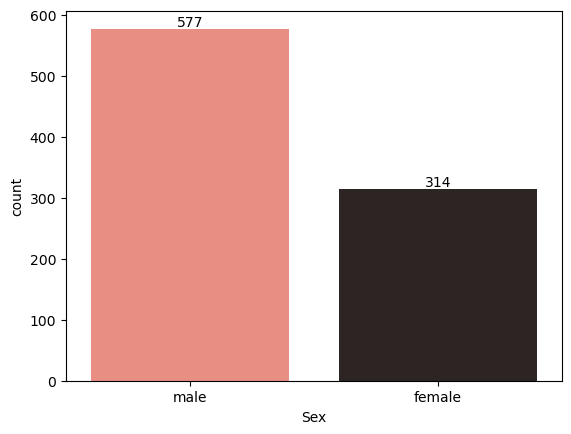

In [13]:
def count_plot(b):
    sell = sns.countplot(x=b, palette = 'dark:salmon_r')
    for container in sell.containers:
        sell.bar_label(container)

count_plot(df['Sex'])

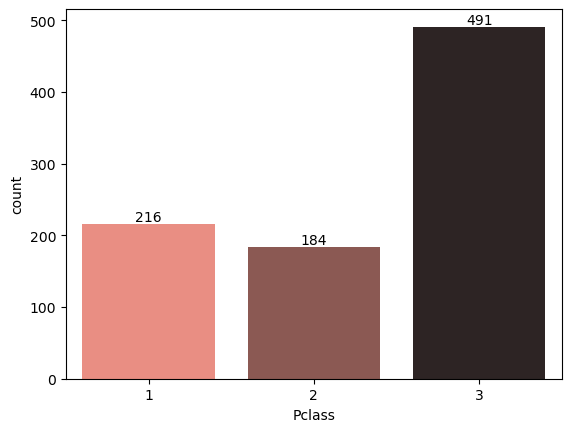

In [14]:
count_plot(df['Pclass'])

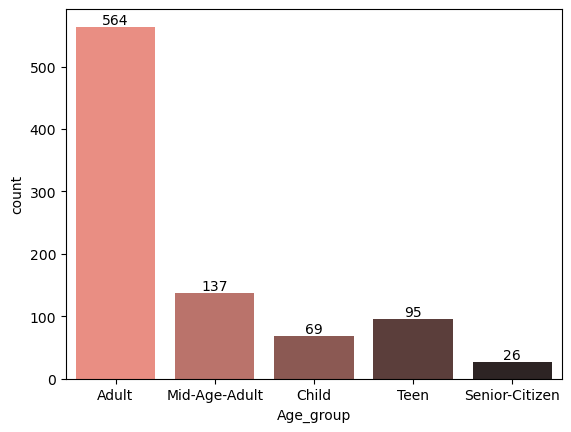

In [20]:
count_plot(df['Age_group'])

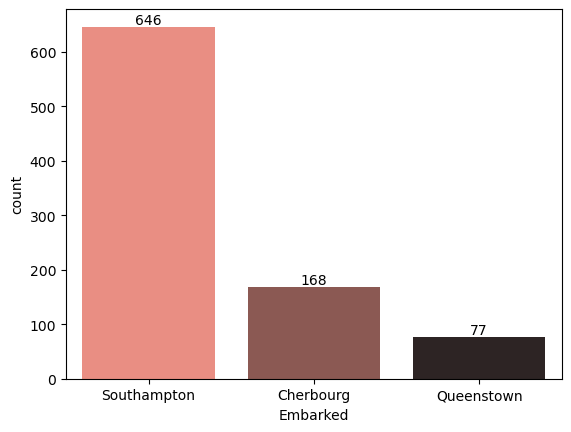

In [17]:
count_plot(df['Embarked'])

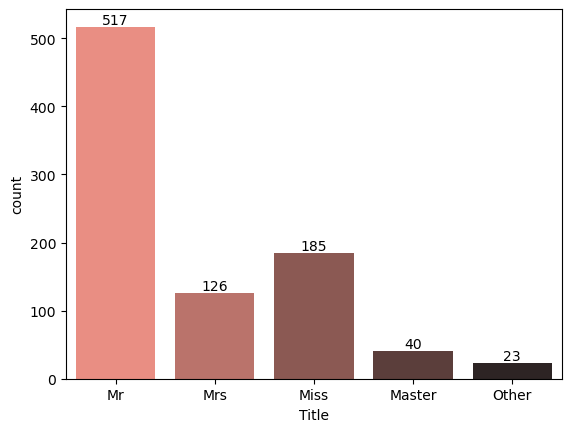

In [18]:
count_plot(df['Title'])

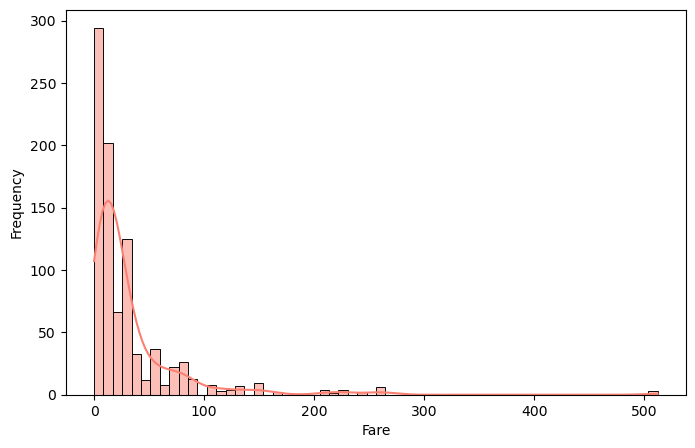

In [48]:
plt.figure(figsize=(8,5))
sns.histplot(df['Fare'], kde=True, color='salmon')
plt.xlabel("Fare")
plt.ylabel("Frequency")
plt.show()

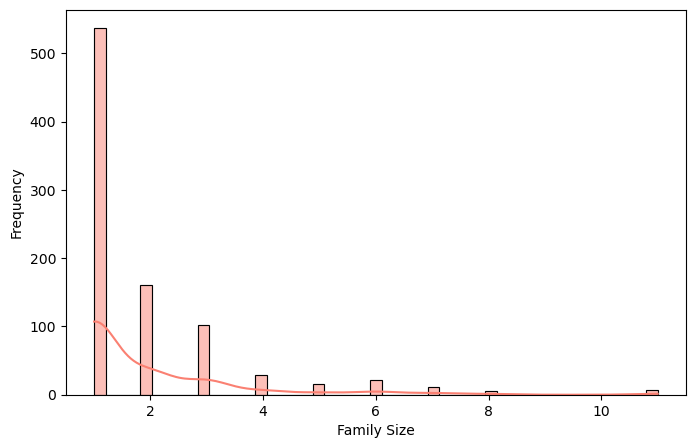

In [22]:
plt.figure(figsize=(8,5))
sns.histplot(df['Family_Size'], kde=True, color='salmon')
plt.xlabel("Family Size")
plt.ylabel("Frequency")
plt.show()

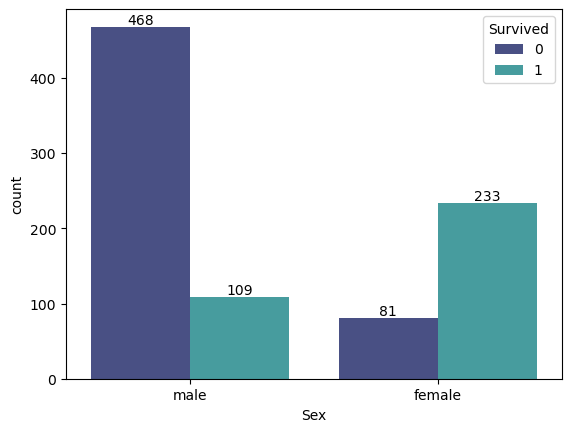

In [57]:
def count_plot(a):
    xyz = sns.countplot(x=a, hue=df['Survived'], palette="mako")
    for container in xyz.containers:
        xyz.bar_label(container)

count_plot(df['Sex'])

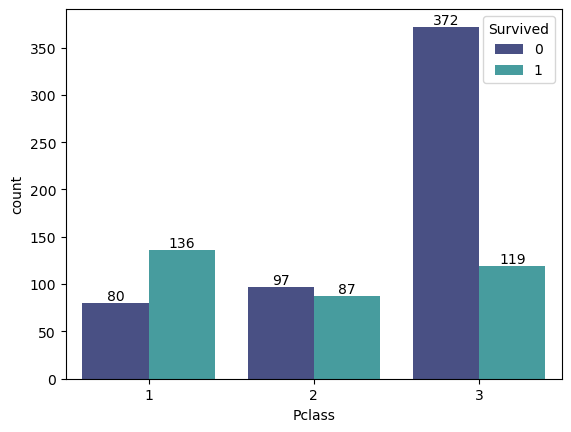

In [58]:
count_plot(df['Pclass'])

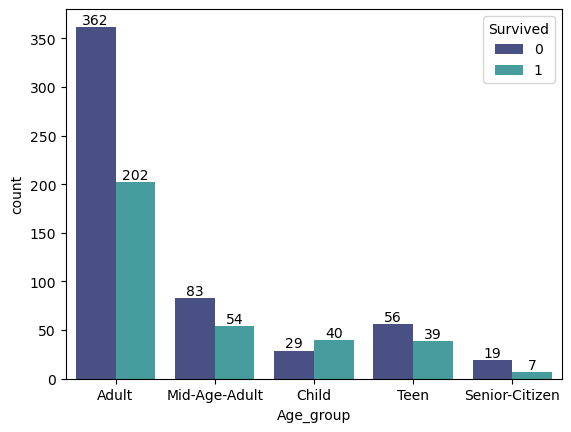

In [59]:
count_plot(df['Age_group'])

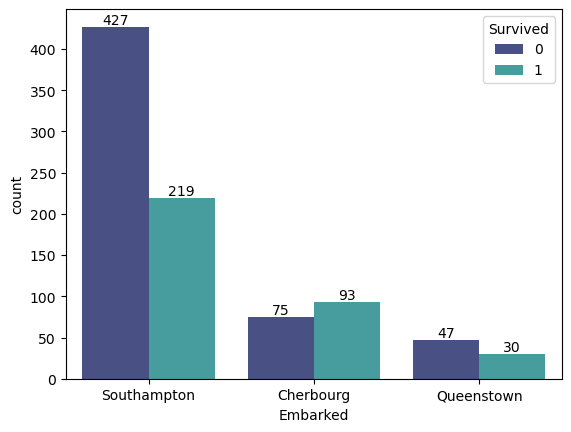

In [60]:
count_plot(df['Embarked'])

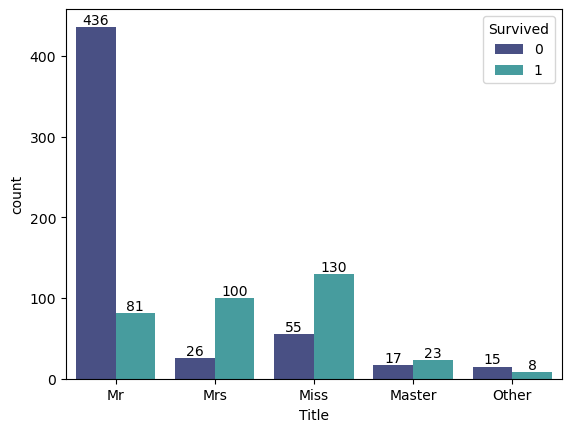

In [61]:
count_plot(df['Title'])

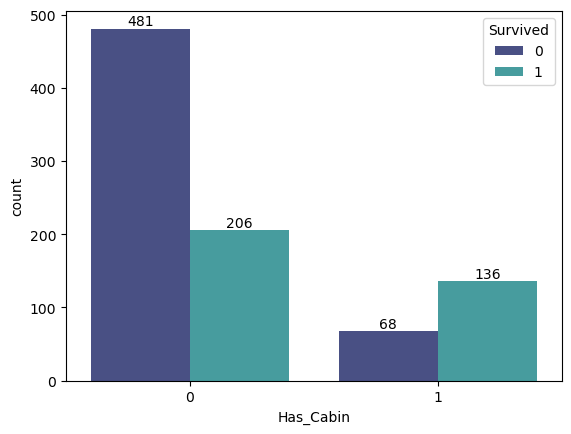

In [62]:
count_plot(df['Has_Cabin'])

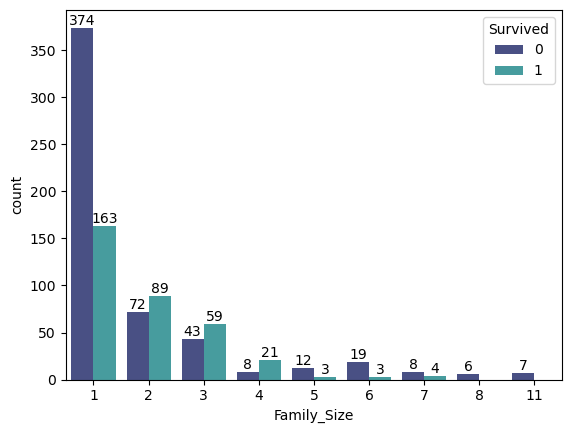

In [63]:
count_plot(df['Family_Size'])

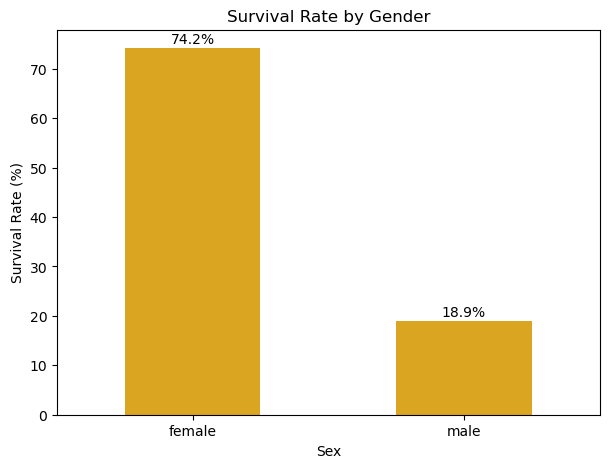

In [70]:
def survival_rate_plot(col, title):
    rate = df.groupby(col)['Survived'].mean() * 100
    ax = rate.sort_values(ascending=False).plot(kind='bar', color='goldenrod', figsize=(7,5))
    ax.set_ylabel("Survival Rate (%)")
    ax.set_title(title)
    for i, v in enumerate(rate.sort_values(ascending=False)):
        ax.text(i, v + 1, f"{v:.1f}%", ha='center')
    plt.xticks(rotation=0)
    plt.show()

survival_rate_plot('Sex', 'Survival Rate by Gender')

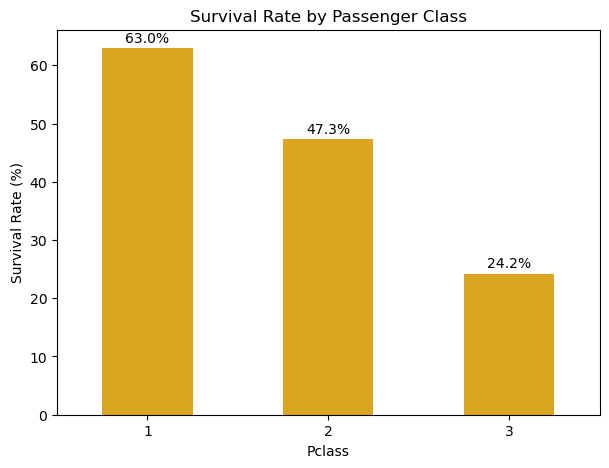

In [71]:
survival_rate_plot('Pclass', 'Survival Rate by Passenger Class')

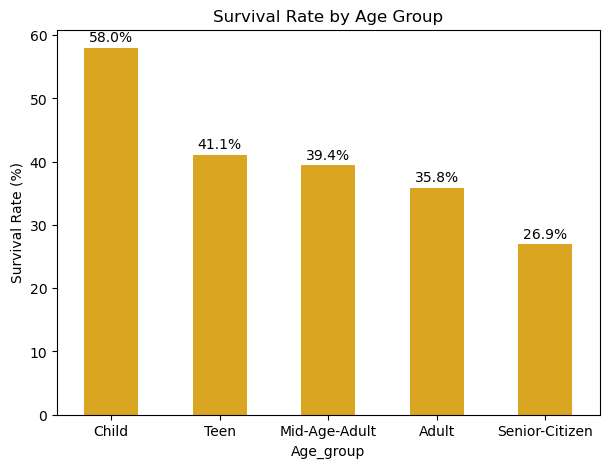

In [72]:
survival_rate_plot('Age_group', 'Survival Rate by Age Group')

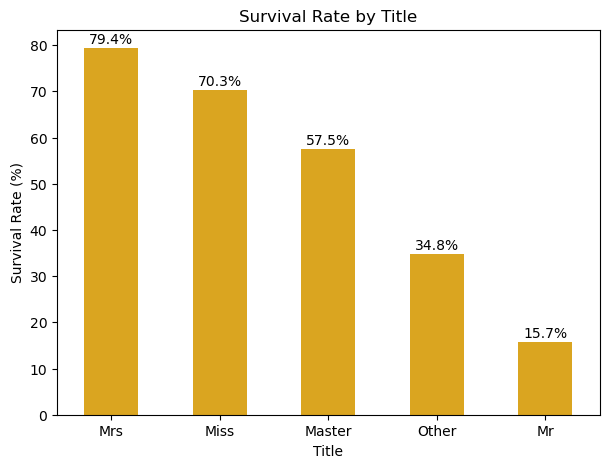

In [73]:
survival_rate_plot('Title', 'Survival Rate by Title')

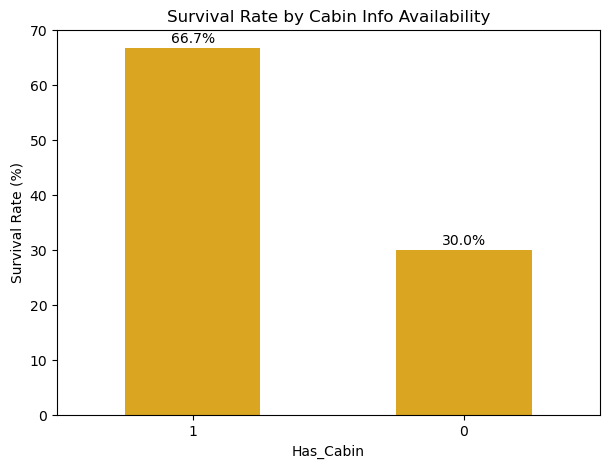

In [74]:
survival_rate_plot('Has_Cabin', 'Survival Rate by Cabin Info Availability')